_Information:_

This notebook is the summary and result of the classification and regression tasks compiled and evaluated in the other notebooks. The process here is the following:
1. Clean the dataset.
2. Visualisations of the dataset.
3. Classification using XGBoost, which was the best method obatined for the classification task.
4. Regression on the obtained songs as hits to obtain their popularity score using the Hybrid model, which is the best method obtained for regression task.
5. XAI on Classification and regression tasks.

# Set up

In [1]:
pip install tensorflow_decision_forests

INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 31.5 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.20.0
    Uninstalling tensorboard-2.20.0:
      Successfully uninstalled tensorboard-2.20.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0
  Attempting uninstall: tf_keras
    Found existing installation: tf_keras 2.20.0
    Uninstalling tf_keras-2.20.0:
      Successfully uninstalled tf_keras-2.20.0
ERROR: pip's dependency resolver 

In [2]:
pip install tensorflow

In [3]:
pip install umap-learn

In [4]:
pip install xgboost

In [5]:
pip install shap

In [6]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=84cf7c92ba74509d4800c12cee47322452c849774f25e88046d9dc033e2ce58b
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [7]:
#Base library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
#Metrics
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
#Classification
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)
#Regression
from sklearn.metrics import  mean_absolute_error, mean_squared_error, r2_score, PredictionErrorDisplay, mean_absolute_error, mean_squared_error, r2_score

In [9]:
#XAI
import shap
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from lime import lime_tabular

In [10]:
#Stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [11]:
#NN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import AveragePooling2D, Input, Flatten, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras import layers, models

In [12]:
import umap

In [13]:
#Classification
import xgboost as xgb

In [14]:
#Regression
import tensorflow_decision_forests as tfdf

In [15]:
import os
import warnings
warnings.filterwarnings("ignore")

# Dataset

## Load and clean

In [17]:
data = pd.read_csv("spotify_dataset.csv").copy()

Duplicates come with different popularity score, first the df will be sorted by popularity and track id in order to drop the duplicates with the lower popularity score.

In [18]:
df_sorted = data.sort_values(by=['popularity', 'track_id'], ascending=[False, True], kind='mergesort')
df_cleaned = df_sorted.drop_duplicates(subset='track_id', keep='first')
df = df_cleaned.copy()

The objective is identify if the songs are hit, thus the tracks that are not of musical genre are discarded.

In [19]:
#Remove comedy, kids, children
df = df[df['track_genre'] != 'comedy']
df = df[df['track_genre'] != 'kids']
df = df[df['track_genre'] != 'children']
#Convert into numeric values
df['explicit'].replace({False: 0, True: 1}, inplace=True)

The columns to be discarded based on their relevance and literature recommendation (key). Track_genre is discarded since the genres may be not completely accurate.

In [20]:
#This will be used to get the osngs name
df_info = df.copy()

In [21]:
drop_cols = [
    "Unnamed: 0",
    "track_id",
    "track_name",
    "album_name",
    "artists",
    'track_genre',
    'key'
]
feature_cols = [c for c in df.columns if c not in drop_cols]

df = df[feature_cols].copy()

In [22]:
#Identify numeric and categorical features
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Categorical features: []


The objective is differenciate songs that are are hit or not, a song with popularity 0 can be considered a non-hit, however this task has to focused on a hit song and it has to learn more about positive characteristics, therefore all songs with popularity = 0 are discarded.

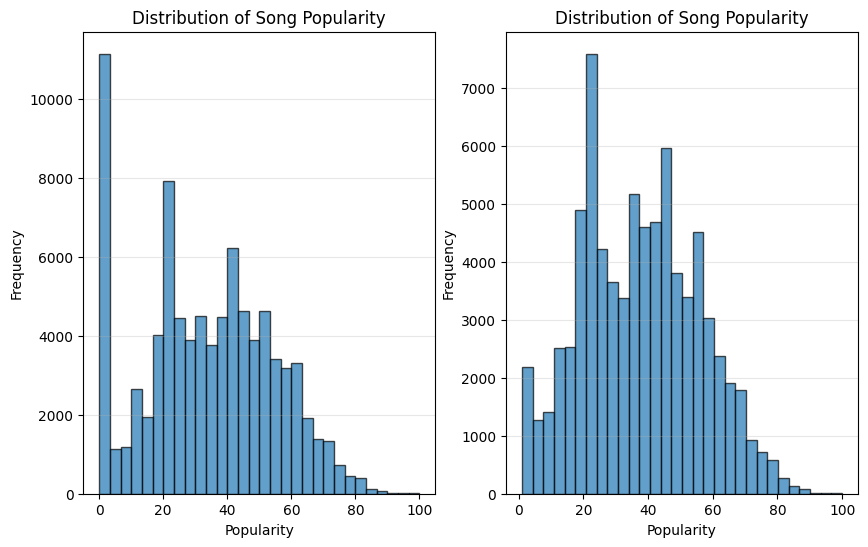

In [23]:
#Histogram of popularity distribution before and after dropping zero popularity songs
plt.figure(figsize=(10, 6))
plt.subplot(121)
plt.hist(df['popularity'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.title('Distribution of Song Popularity')
plt.grid(axis='y', alpha=0.3)
plt.subplot(122)
plt.hist(df[df['popularity'] > 0]['popularity'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.title('Distribution of Song Popularity')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [24]:
df = df[df['popularity'] > 0]

To establish song that can be considered as hit or not, it was set a threshold based on the median, since the median is the value that is approximately at the middle of the data.

In [25]:
median = df['popularity'].median()
median

37.0

In [26]:
#Define is hit if the popularity is greater or equal than the median
df["is_hit"] = (df["popularity"] >= int(median)).astype(int)

To know the size of the df and the proportion of the classes

In [27]:
print(df.shape)
print(df["is_hit"].value_counts())
print(df["is_hit"].value_counts(normalize=True))
df.head()

(77580, 15)
is_hit
1    40181
0    37399
Name: count, dtype: int64
is_hit
1    0.51793
0    0.48207
Name: proportion, dtype: float64


,popularity,duration_ms,explicit,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,is_hit
20001,100,156943,0,0.714,0.472,-7.375,1,0.0864,0.01300,0.000005,0.266,0.238,131.121,4,1
51664,99,198937,0,0.621,0.782,-5.548,1,0.0440,0.01250,0.033000,0.230,0.550,128.033,4,1
20008,98,175238,1,0.561,0.965,-3.673,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,1
67356,98,162637,0,0.835,0.679,-5.329,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,1
67359,97,243716,0,0.650,0.715,-5.198,0,0.2530,0.09930,0.000291,0.126,0.187,106.672,4,1


From the above results, the accuracy to overcome is **0.51**

In [28]:
#Define the variables to work on
y_reg = df['popularity'] #This will be stored to compare fot the regression task
y = df['is_hit']
#Drop popularity because it is the target variable
df = df.drop(['popularity'], axis=1)
X = df.drop(columns=['is_hit'])

## Correlation

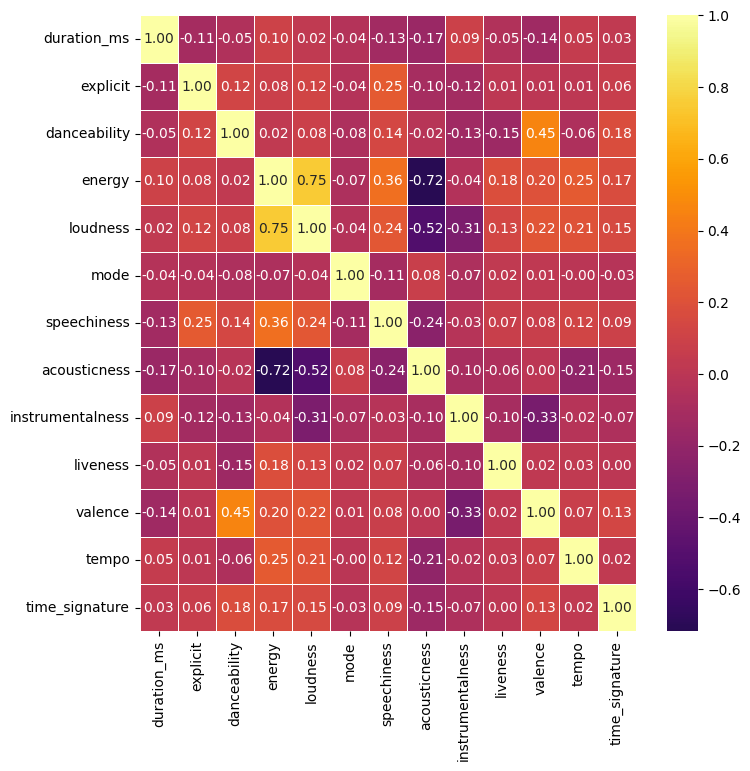

In [29]:
#Correlation between predictors
plt.figure(figsize = (8,8))
matrix = X.corr(method = 'spearman')
sns.heatmap(matrix, cmap='inferno', center=0, square=False, linewidths=0.5, annot=True, fmt=".2f"   )
plt.show()

## VIF for colinearity
Since some variables can be related acousticness, instrumentalness, etc

In [30]:
X_vif = add_constant(X)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

vif_results = vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF", ascending=False)

print(vif_results)

             Feature       VIF
4             energy  4.262688
5           loudness  3.268466
8       acousticness  2.403198
11           valence  1.577529
3       danceability  1.527285
9   instrumentalness  1.477378
7        speechiness  1.151814
2           explicit  1.125796
12             tempo  1.098503
10          liveness  1.097398
13    time_signature  1.084867
1        duration_ms  1.053395
6               mode  1.023596


Since none of the variables have a VIF greater than 5, none variables are discarded.

Redefine each type of columns

In [31]:
#Numeric
numeric_features = ['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
#Categorical
categorical_features = ['time_signature']
#Binary
binary_features = ['mode', 'explicit']

Preprocess the data by their type

In [32]:
#Preprocessor
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

binary_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("bin", "passthrough")
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
    ("bin", binary_transformer, binary_features)
])

## Split data

To avoid data leakage the flow will be:
1. Split the data.
2. Transform it using the preprocessor defined above.

In [33]:
X_train, X_test, y_train,  y_test, y_reg_train, y_reg_test = train_test_split(
    X, y, y_reg,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())
print(y_reg_train.mean(), y_reg_test.mean())

(62064, 13) (15516, 13)
0.5179331013147719 0.5179169889146688
37.45759216292859 37.53531838102604


In [34]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [35]:
column_names = preprocessor.get_feature_names_out()

## UMAP

Note: here the UMAP will be applied on the trainin set since it takes so much time to be compute, this is only to have a refernce of the variables behaviour

In [36]:
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    low_memory=True,
    random_state=42
)

In [37]:
embedding = reducer.fit_transform(X_test_scaled)

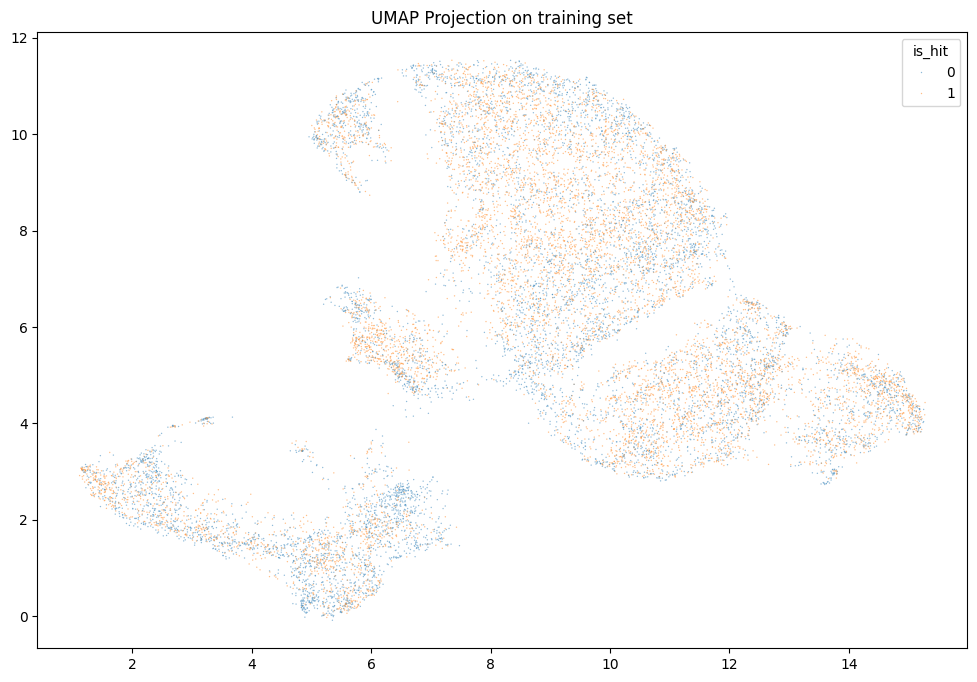

In [38]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_test, s=1, alpha=0.5)
plt.title('UMAP Projection on training set')
plt.show()

The UMAP above indicates sthat the classes are actually hard to be distinguished

# Classification

The best ethod obtained for the classification task was XGBoost.

The defined dictiorary was obatined through a GridSearchCV, more information in the classification notebook.

In [39]:
best_params = {'colsample_bytree': 1,
               'gamma': 0,
               'learning_rate': 0.01,
               'max_depth': 8,
               'min_child_weight': 0,
               'n_estimators': 600,
               'random_state': 2000,
               'subsample': 0.8}

classifier = xgb.XGBClassifier()

In [40]:
classifier.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [41]:
#Get the predictions and their probabilities
y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)[:, 1]

Metrics

In [42]:
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1-score :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=['Non-Hit', 'Hit']))

Accuracy : 0.6689
Precision: 0.6613
Recall   : 0.7395
F1-score : 0.6982
ROC AUC  : 0.7325

Classification report:

              precision    recall  f1-score   support

     Non-Hit       0.68      0.59      0.63      7480
         Hit       0.66      0.74      0.70      8036

    accuracy                           0.67     15516
   macro avg       0.67      0.67      0.67     15516
weighted avg       0.67      0.67      0.67     15516



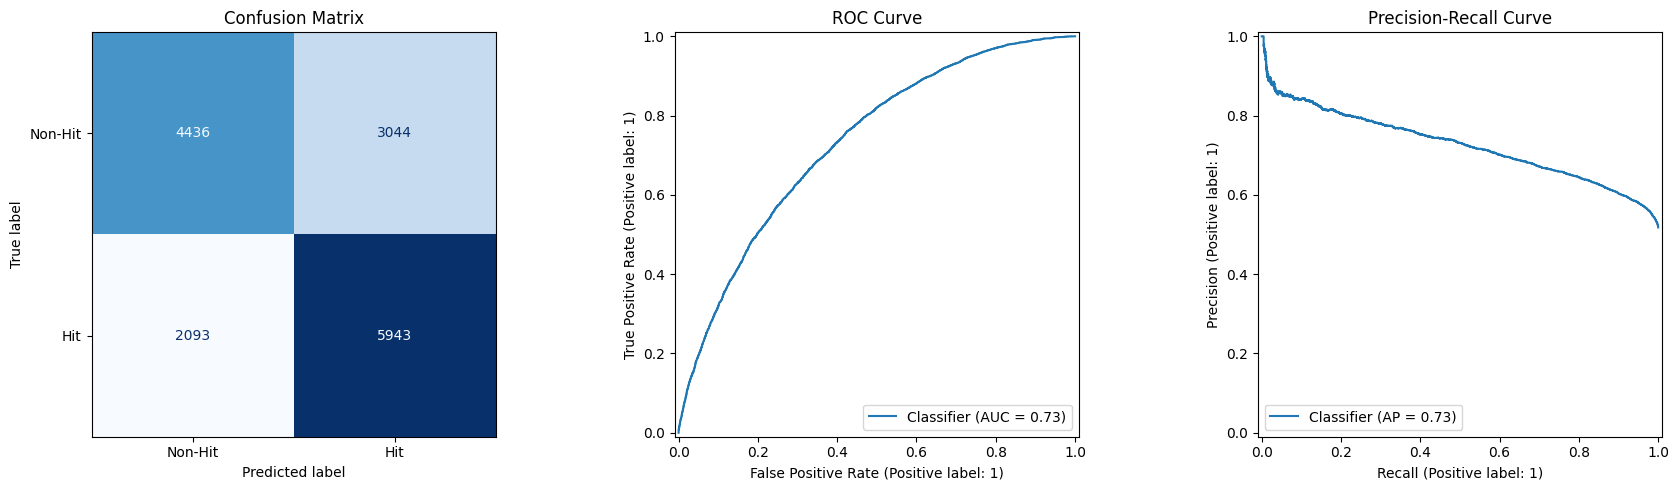

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Non-Hit", "Hit"],
    colorbar=False,
    cmap='Blues',
    ax=axes[0])
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2])
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

During the trainings a feature importance plot was obatined to consider droppig some of the variables, however when dropping variables, the regression task performance decrease. The feature importance plot obtained is the following.

In [44]:
#Get importance
xgb_importances = classifier.feature_importances_
feature_names = X_train.columns
xgb_feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': xgb_importances})
xgb_feature_importance_df = xgb_feature_importance_df.sort_values(by='Importance', ascending=False)

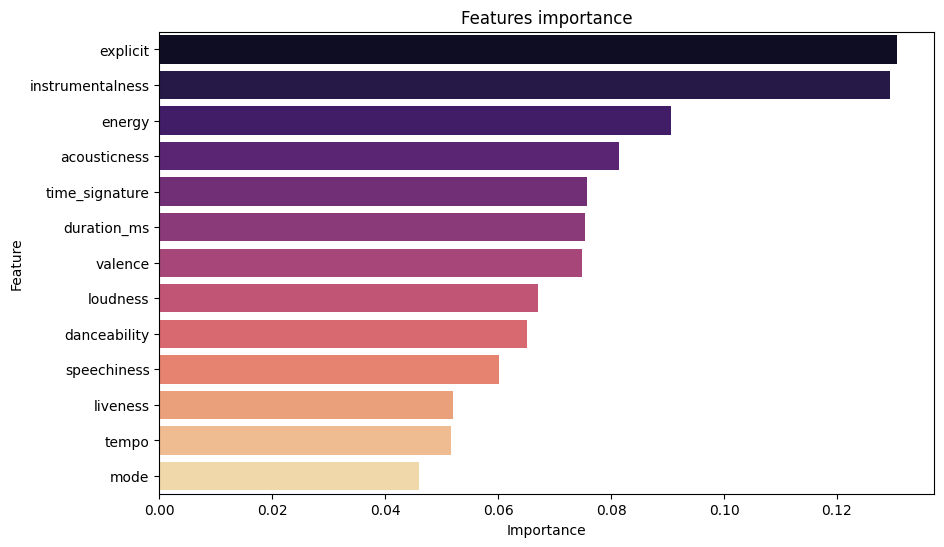

In [45]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=xgb_feature_importance_df, palette='magma')
plt.title('Features importance')
plt.show()

## XAI

### Permutation feature importance
To know which features XGBoost considered to classify a son as a hit.

             feature  importance_mean  importance_std
3             energy         0.050118        0.001617
10           valence         0.044722        0.001083
8   instrumentalness         0.042977        0.002139
7       acousticness         0.042050        0.000918
2       danceability         0.040320        0.001970
4           loudness         0.039003        0.002335
0        duration_ms         0.035386        0.002033
11             tempo         0.021061        0.001385
6        speechiness         0.016672        0.001515
9           liveness         0.011880        0.000919
1           explicit         0.007717        0.000759
12    time_signature         0.002877        0.000433
5               mode         0.001826        0.000295


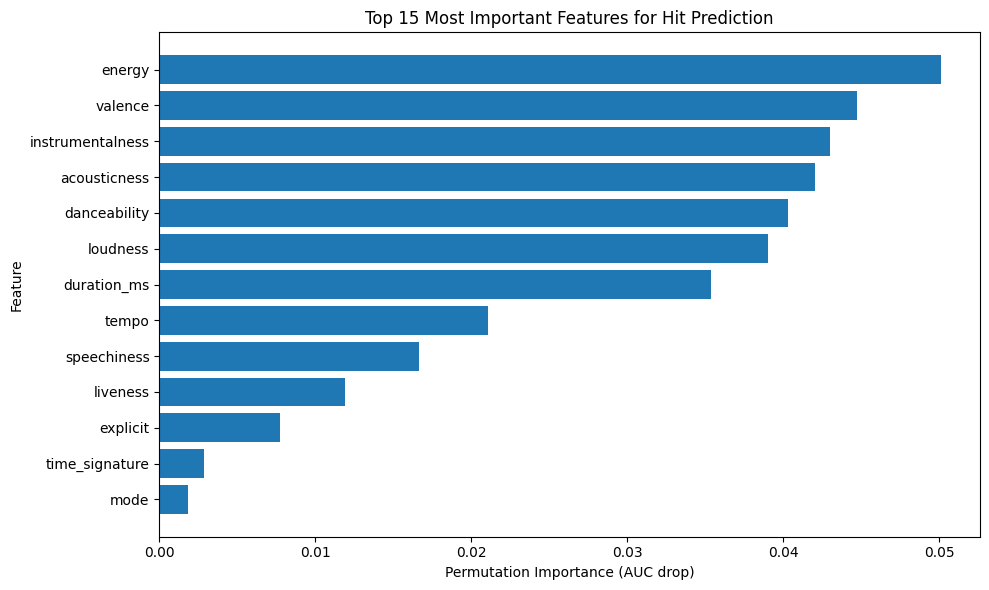

In [46]:
perm = permutation_importance(
    classifier,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_df.head(15))

plt.figure(figsize=(10, 6))
top_perm = perm_df.head(15).sort_values("importance_mean")
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.xlabel("Permutation Importance (AUC drop)")
plt.ylabel("Feature")
plt.title("Top 15 Most Important Features for Hit Prediction")
plt.tight_layout()
plt.show()

### SHAP
Understand the taken path for the classification

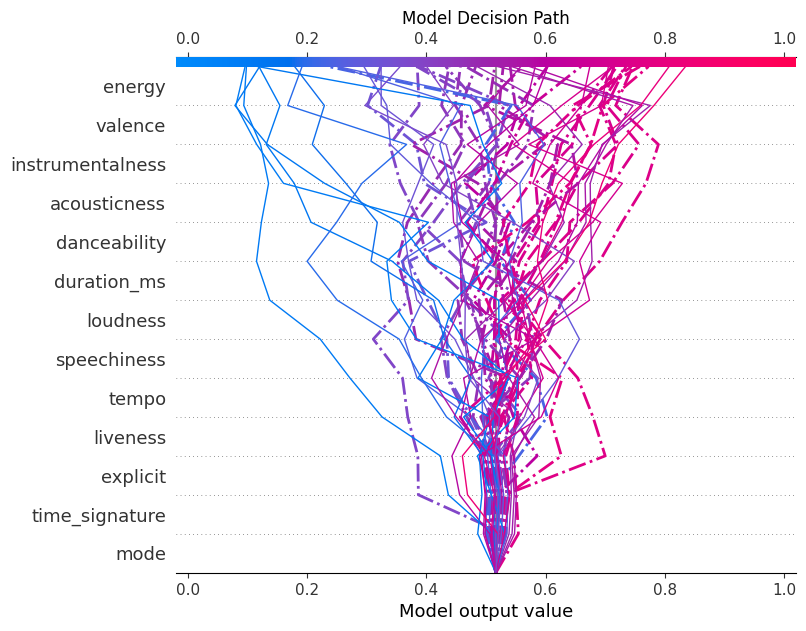

In [47]:
#Take 25 random samples of each class
X_hit = X_test[y_test == 1].sample(25, random_state=42)
X_nonhit = X_test[y_test == 0].sample(25, random_state=42)
X_explained = pd.concat([X_hit, X_nonhit])
y_labels = y_test.loc[X_explained.index]

#Explain model
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_explained)

shap.decision_plot(
    explainer.expected_value,
    shap_values,
    X_explained,
    link='logit',
    highlight=np.where(y_labels == 1)[0],
    title='Model Decision Path'
)

# Regression

The best second model obtained was Hybrid NN + RF, XGBoost was the first one, however, the scope of this project is the use of neural networks, therefore the implementation of the hybrid architecture will be used.
**For this is necessary the use of colab**

## **1. Get all the XGBoost's hits**

In [48]:
#Hit's mask
hits_masked = (y_pred == 1)

In [49]:
X_test_hits = X_test_scaled[hits_masked]
y_popularity = y_reg_test[hits_masked]

In [50]:
#Total songs and hit sonngs
print(f'Number of songs in the test set: {len(X_test_scaled)}\nNumber of songs classified as hits:{len(X_test_hits)}')

Number of songs in the test set: 15516
Number of songs classified as hits:8987


## 2. Format the dataset into tensorflow format

In [51]:
#Change the train and test dataset into a tensorflow format it is X and y train/test together in one dataset
##Train
train_df = pd.DataFrame(X_train_scaled, columns=column_names) #Since the X will get inside the NN
train_df['target_popularity'] = y_reg_train.values #Not transformed since this will be inside the RF
##Test (only using the obtained hits)
##Test
test_df = pd.DataFrame(X_test_hits, columns=column_names)
test_df['target_popularity'] = y_popularity.values
#tf dataset format
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_df, label='target_popularity', task=tfdf.keras.Task.REGRESSION)
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(test_df, label='target_popularity', task=tfdf.keras.Task.REGRESSION)

In [52]:
#Since the model is hybrid, the input has to be modified to be accepted by the NN
#Toggle Gemini generated this
inputs = {}
for col_name in column_names:
    # Each input feature is a scalar (shape=(1,))
    inputs[col_name] = keras.Input(shape=(1,), name=col_name)

# Concatenate all input features
concatenated_inputs = layers.concatenate(list(inputs.values()))

## 3. Define the NN architecture to extract features

In [53]:
#Define Neural Network layers (using the NN defined on the paper which reached the highest R²)
x = layers.Dense(4096, activation='swish')(concatenated_inputs)
x = layers.Dense(40)(x)

In [54]:
nn_model = models.Model(inputs=inputs, outputs=x)
#Add the NN architecture into the RFM from keras
hybrid_model = tfdf.keras.RandomForestModel(
    preprocessing=nn_model,
    task=tfdf.keras.Task.REGRESSION)
hybrid_model.compile(optimizer='adam',loss=tf.keras.losses.Huber(), metrics=["mae", "mse"])

Use /tmp/tmp2hurophe as temporary training directory


## 4. Train the model on the train data as the classifier

In [55]:
#Train the new model
hybrid_model.fit(train_ds)

Reading training dataset...
Training dataset read in 0:00:09.555006. Found 62064 examples.
Training model...
Model trained in 0:03:35.611816
Compiling model...
Model compiled.


## **5. Get the popularity score of the hit songs obtained from the classification step**

In [56]:
y_pop_pred = hybrid_model.predict(test_ds)

9/9 [==============================] - 2s 164ms/step


## 6. Evaluation

In [57]:
print("MAE (Mean Aboslute Error): ", round(mean_absolute_error(y_popularity, y_pop_pred), 4))
print("MSE (Mean Square Error): ", round(mean_squared_error(y_popularity, y_pop_pred), 4))
print("RMSE (Root Mean Square Error): ", round(np.sqrt(mean_squared_error(y_popularity, y_pop_pred)), 4))
print("R2 Score: ", round(r2_score(y_popularity, y_pop_pred), 4))

MAE (Mean Aboslute Error):  13.3992
MSE (Mean Square Error):  283.5887
RMSE (Root Mean Square Error):  16.8401
R2 Score:  0.0548


**Get the names and artists of the songs for feature tasks**

In [58]:
df_pop = pd.DataFrame({
    'Artist': df_info.loc[y_popularity.index, 'artists'],
    'Track name': df_info.loc[y_popularity.index, 'track_name'],
    'Real popularity': y_popularity,
    'Predicted popularity': y_pop_pred.flatten(),
    'Absolute error': np.abs(y_popularity - y_pop_pred.flatten())
})

In [156]:
df_pop.sort_values(by='Real popularity', ascending=False).head(10)

,Artist,Track name,Real popularity,Predicted popularity,Absolute error
51664,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52",99,41.430058,57.569942
20008,David Guetta;Bebe Rexha,I'm Good (Blue),98,37.299492,60.700508
67356,Manuel Turizo,La Bachata,98,43.006199,54.993801
67500,Bad Bunny;Bomba Estéreo,Ojitos Lindos,95,46.261745,48.738255
88408,KAROL G,PROVENZA,93,31.351404,61.648596
20017,Charlie Puth;Jung Kook;BTS,Left and Right (Feat. Jung Kook of BTS),92,32.457558,59.542442
67865,Bad Bunny;Jhayco,Tarot,91,45.099819,45.900181
20811,James Hype;Miggy Dela Rosa,Ferrari,90,37.895374,52.104626
34014,Seafret,Atlantis,90,45.806358,44.193642
68673,Bad Bunny;Tony Dize,La Corriente,90,44.442768,45.557232


In [157]:
df_pop.sort_values(by='Real popularity', ascending=True).head(10)

,Artist,Track name,Real popularity,Predicted popularity,Absolute error
2178,Marilyn Manson,The Fight Song,1,38.552769,37.552769
99245,Alanis Morissette,You Oughta Know,1,42.780323,41.780323
20527,Avicii,The Nights,1,40.747547,39.747547
91274,Bastille,Thelma + Louise,1,46.727173,45.727173
3373,Bella Poarch,Living Hell,1,43.650921,42.650921
56891,Cesare Cremonini,Lost In The Weekend,1,46.127728,45.127728
2279,Godsmack,Cryin' Like A Bitch!!,1,48.954430,47.954430
20426,Tiësto;Charli XCX,Hot in It,1,35.971325,34.971325
20093,David Guetta;Becky Hill;Ella Henderson,Crazy What Love Can Do,1,45.729748,44.729748
20340,Shawn Mendes,Stitches,1,43.276726,42.276726


## XAI

Here the PDP & ICE will be splitted for the first part of the hybrid model (NN), then for the RF implementation.

### NN

In [125]:
top_features = ['num__energy', 'num__valence', 'num__instrumentalness', 'num__acousticness']

In [141]:
class KerasWrapper:
    def __init__(self, model, feature_names):
        self.model = model
        self.feature_names = feature_names
        self._estimator_type = "regressor"

    def fit(self, X, y=None):
        return self

    def __sklearn_is_fitted__(self):
        return True

    def predict(self, X):
        # The Keras model expects a dictionary for multi-input functional API
        if isinstance(X, pd.DataFrame):
            X_dict = {col: X[col].values for col in X.columns}
        else:
            X_dict = {self.feature_names[i]: X[:, i] for i in range(len(self.feature_names))}

        y_pred = self.model.predict(X_dict, verbose=0)
        return y_pred.flatten()

# Re-wrap the model with feature names mapping
wrapped_model = KerasWrapper(nn_model, column_names)

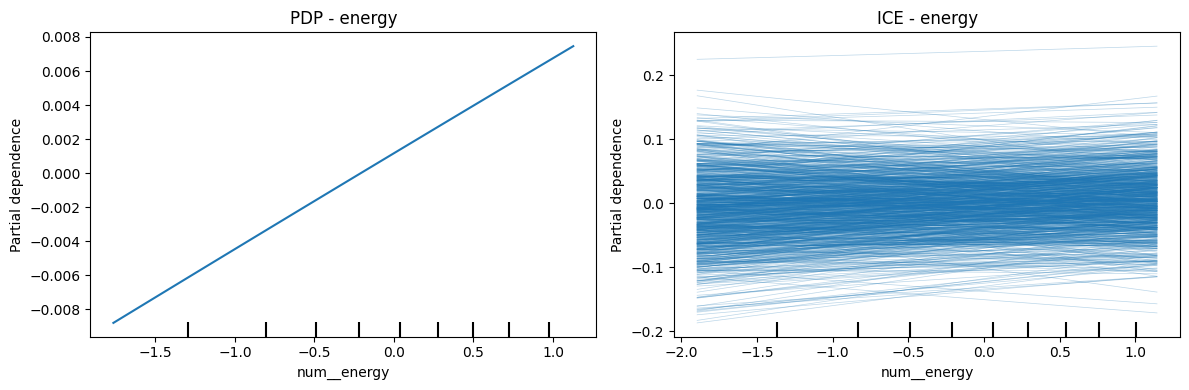

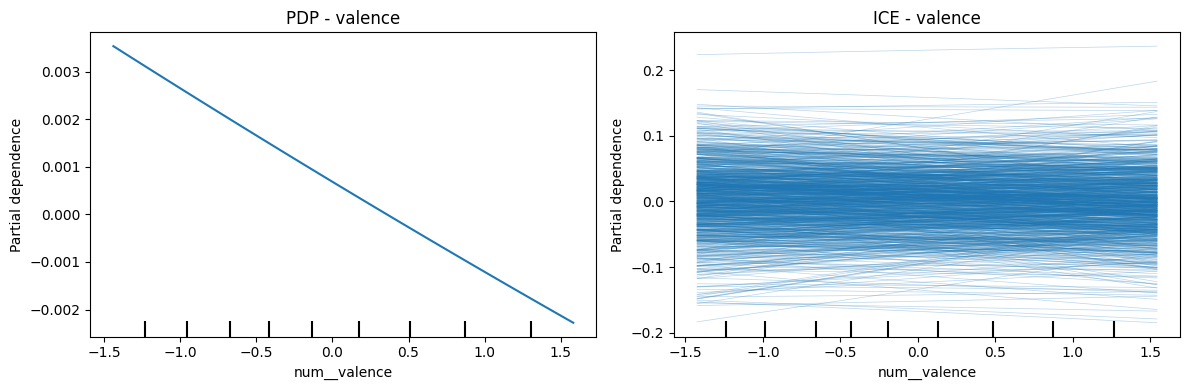

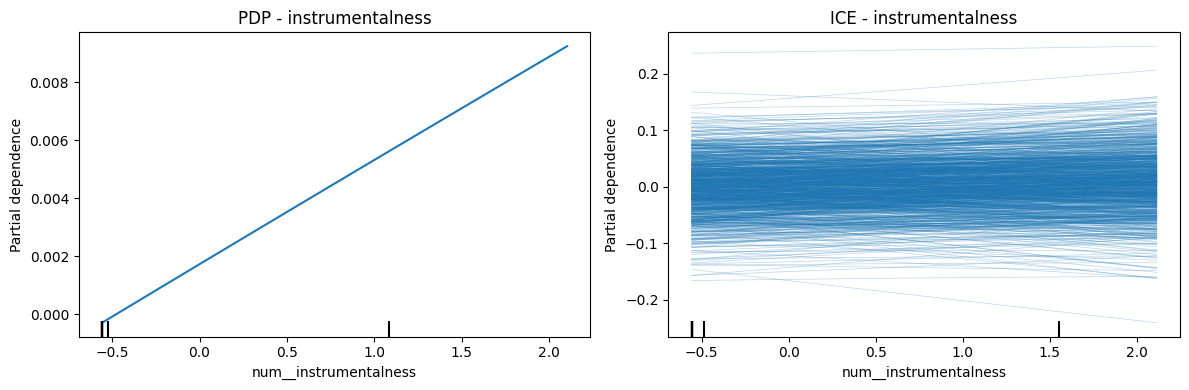

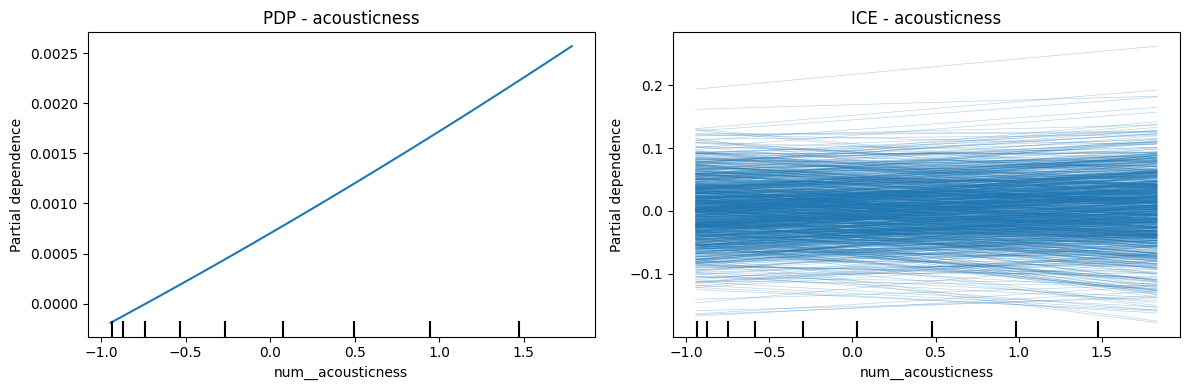

In [143]:
X_test_df = pd.DataFrame(X_test_hits, columns=column_names)

for feature in top_features:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Added target=0 because the NN output dimension is 40
    PartialDependenceDisplay.from_estimator(
        wrapped_model,
        X_test_df,
        features=[feature],
        kind="average",
        target=0,
        ax=ax[0]
    )
    ax[0].set_title(f"PDP - {feature.replace('num__', '')}")

    PartialDependenceDisplay.from_estimator(
        wrapped_model,
        X_test_df.sample(min(1000, len(X_test_df)), random_state=42),
        features=[feature],
        kind="individual",
        target=0,
        ax=ax[1]
    )
    ax[1].set_title(f"ICE - {feature.replace('num__', '')}")

    plt.tight_layout()
    plt.show()

Interaction features: ['num__energy', 'num__valence']


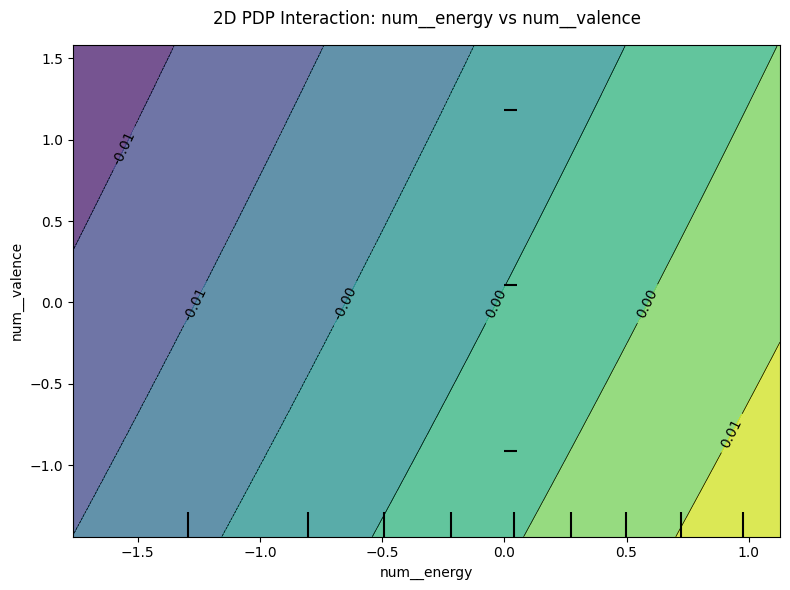

In [147]:
print("Interaction features:", top_features[:2])
#Define the interactions variables
top_int = top_features[:2]
if len(top_int) == 2:
    fig, ax = plt.subplots(figsize=(8, 6))
    PartialDependenceDisplay.from_estimator(
        wrapped_model,
        X_test_df,
        features=[(top_int[0], top_int[1])],
        grid_resolution=20,
        target=0, # Specify the first output of the 40-neuron layer
        ax=ax
    )

    ax.set_title(f"2D PDP Interaction: {top_int[0]} vs {top_int[1]}", fontsize=12, pad=15)

    plt.tight_layout()
    plt.show()

### Random Forest Model

In [150]:
# Get the neuron outputs (extracted/latent features)
# Using reshaped numpy arrays in a dictionary to ensure consistent input shapes
nn_inputs_hits = {col_name: X_test_df[col_name].values.reshape(-1, 1).astype('float32') for col_name in column_names}

# Using the model directly can be more robust for feature extraction in functional APIs
# We convert to a tensor to ensure TensorFlow handles the metadata correctly
X_test_nn = nn_model(nn_inputs_hits, training=False).numpy()

In [151]:
#Look how the output from the NN (the input for RFM) is
print(f'Shape: {X_test_nn.shape}')

Shape: (8987, 40)


In [152]:
#Get the inspector to know the RFM behaviour (the hybrid model trained above)
inspector = hybrid_model.make_inspector()
#Get the importanceof the variables
importances = inspector.variable_importances()["NUM_AS_ROOT"]

In [159]:
#Look the feature importance of the neurons
df_imp_nn = pd.DataFrame([{"Embedding/Linear output": f, "Importance": val} for f, val in importances])
print(df_imp_nn.head(10))

                        Embedding/Linear output  Importance
0  (functional_1/dense_1_2/BiasAdd:0.38, 1, 33)       103.0
1  (functional_1/dense_1_2/BiasAdd:0.29, 1, 23)        69.0
2   (functional_1/dense_1_2/BiasAdd:0.2, 1, 13)        46.0
3  (functional_1/dense_1_2/BiasAdd:0.20, 1, 14)        29.0
4   (functional_1/dense_1_2/BiasAdd:0.14, 1, 7)        22.0
5   (functional_1/dense_1_2/BiasAdd:0.4, 1, 35)        20.0
6  (functional_1/dense_1_2/BiasAdd:0.25, 1, 19)         5.0
7   (functional_1/dense_1_2/BiasAdd:0.13, 1, 6)         4.0
8   (functional_1/dense_1_2/BiasAdd:0.10, 1, 3)         1.0
9   (functional_1/dense_1_2/BiasAdd:0.3, 1, 24)         1.0


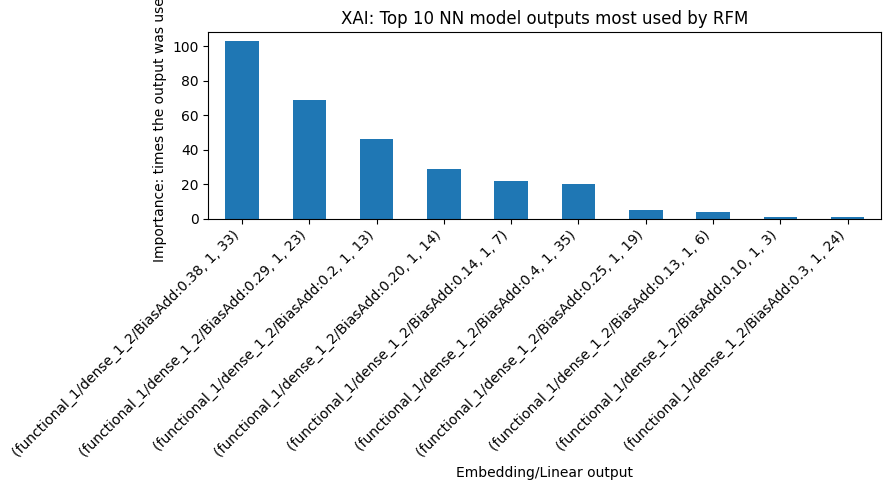

In [163]:
plt.figure(figsize=(9, 5))
df_imp_nn.head(10).plot(kind='bar', x='Embedding/Linear output', y='Importance', legend=False, ax=plt.gca())
plt.title("XAI: Top 10 NN model outputs most used by RFM")
plt.ylabel("Importance: times the output was used")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()